# 0 - Imports

In these first sections we will cover installations of all libraries taking into account the platform in which this notebook will be executed

## 0.1 Colab Setting

In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !pip install ftfy regex tqdm
    !pip install git+https://github.com/openai/CLIP.git
    !pip install torchmetrics
    !pip3 install torch torchvision torchaudio
    !pip install -U ultralytics
else:
    print("Not running on Google Colab")


Not running on Google Colab


In [4]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Put your Colab-only code here
    print("Running on Google Colab")
    !mkdir dataset
    !gdown 1A_ezza3Bj3OJv8wgTyIsLynNqqztRwl4
    !ls
    !mv Uploaded_refcocog.tar.gz ./dataset/
    !ls dataset
else:
    print("Not running on Google Colab")


Not running on Google Colab


## 0.2 Imports

In [5]:
import pickle # Load refs and annotations
import json
import os
import pandas as pd
import numpy as np
import pprint
import json
import cv2
import random
import heapq
from __future__ import  absolute_import
import os
from collections import namedtuple
import time

from typing import Any, Optional

import torch
from torch import nn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.cuda.amp import autocast

import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torchvision.ops import roi_align
from torchvision.utils import draw_bounding_boxes
from torchvision import models
import torchmetrics

import pytorch_lightning as pl
from pytorch_lightning.utilities.types import STEP_OUTPUT

from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import CLIPProcessor, CLIPModel

from tqdm.notebook import tqdm, trange
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import clip
from ultralytics import YOLO
from PIL import Image, ImageDraw
from tabulate import tabulate

from ipywidgets import FloatProgress
import math
from torch.nn.modules.batchnorm import _BatchNorm
from torchvision.ops import box_convert
from torchvision.ops import nms
from torchvision.ops import RoIPool

## 0.3 Tensorboard and Metrics

In [6]:
%load_ext tensorboard

In [7]:
if torch.cuda.is_available():
    print("CUDA backend is available.")
    device = torch.device('cuda')
else:
    print("Neither CUDA or MPS backend are available. Resorting to CPU")
    device = torch.device('cpu')

CUDA backend is available.


In [8]:
log_dir = 'logs'

# 1 - Utils

## 1.1 Helper Functions and Cells

The `plot_images` function displays a list of images in a grid. Used only for displaying purposes

In [9]:
def plot_images(images):
    
    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

In [10]:
def draw_bboxes(image_path, bbox, gt, confidence):
    image = cv2.imread(image_path)

    # Define colors
    max_bbox_color = (0, 255, 0)  # Green for ground truth
    other_bbox_color = (0, 0, 255)  # Red for predictions

    # Plot all bboxes
    cv2.rectangle(image, (int(bbox[0]), int(bbox[1])) ,(int(bbox[2]), int(bbox[3])), other_bbox_color, 2)
    cv2.putText(image, 'Confidence' + str(confidence), (int(bbox[0]), int(bbox[1])-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, other_bbox_color, 2)
    color = max_bbox_color
    cv2.rectangle(image, (int(gt[0]), int(gt[1])) ,(int(gt[2]), int(gt[3])), color, 2)

    # Convert the image from BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    return image_rgb

In [11]:
def plot_images_case(cases):
    images = []

    for i, case in enumerate(cases):
        image_path = os.path.join('', case["path"])
        ground_truth=case["ground_truth"]
        candidate=case["candidate"]
        confidence= case['confidence']
        images.append(draw_bboxes(image_path,candidate,ground_truth,confidence))

    num_images = len(images)
    cols = 3  # Number of columns in the grid
    rows = (num_images // cols) + (num_images % cols > 0)

    # Create a figure to display the images
    plt.figure(figsize=(15, 5 * rows))

    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')  # Hide axes

    plt.show()

'draw_bboxes' is used to confront the extracted `bbox` with the relative `ground_truth`

function to compute the Intersection Over Union of two different bboxes

In [12]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_area = max(0, x2 - x1 + 1) * max(0, y2 - y1 + 1) # +1 to avoid max(0,0) therefore avoiding

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area

In [13]:
def getcaption(elem):
    li = []
    for e in elem["sentences"]:
        li.append(e['raw'])
    return li

In [14]:
with open("../refcocog/annotations/refs(umd).p", "rb") as fp:
  refs = pickle.load(fp)

# 'annotations' will be a dict object mapping the 'annotation_id' to the 'bbox' to make search faster
with open("../refcocog/annotations/instances.json", "rb") as fp:
  data = json.load(fp)
  annotations = dict(sorted({ann["id"]: ann["bbox"] for ann in data["annotations"]}.items()))

In [15]:
def tonumpy(data):
    if isinstance(data, np.ndarray):
        return data
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()


def totensor(data, cuda=False):
    if isinstance(data, np.ndarray):
        tensor = torch.from_numpy(data)
    if isinstance(data, torch.Tensor):
        tensor = data.detach()
    if cuda:
        tensor = tensor.cuda()
    return tensor


def scalar(data):
    if isinstance(data, np.ndarray):
        return data.reshape(1)[0]
    if isinstance(data, torch.Tensor):
        return data.item()

## 1.2 MetricMeter

Class to help track down examples duting runs

In [16]:
model = YOLO('yolov8n.pt') # yolov3-v7
classes = model.names

In [357]:
import os
import heapq
import numpy as np
import pickle
import torch
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

class MetricMeter:
    def __init__(
        self,
        name="Default",
        threshold=0.5,
        log_dir='./logs/default_run',
        save_dir='./metrics',
        mAP_iou_thresholds=[0.5, 0.75],
        conf_threshold_cm=0.5,
        class_names=classes
    ):
        self.name = name
        self.threshold = threshold
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
        self.class_names = class_names or []
        self.num_classes = len(self.class_names)

        self.epoch = 0
        self.writer = SummaryWriter(log_dir=log_dir)
        self.reset()

        # Metrics configuration
        self.mAP_iou_thresholds = mAP_iou_thresholds
        self.conf_threshold_cm = conf_threshold_cm

        # Heaps for best/worst cases
        self.best_cases_iou = []
        self.worst_cases_iou = []
        self.best_cases_sim = []
        self.worst_cases_sim = []

    def reset(self):
        self.count = 0
        self.iou = 0
        self.correct_bboxes = 0
        self.semantic = 0
        self.metrics = []
        
        # Lists to track metrics
        self.iou_list = []
        self.precision_list = []
        self.recall_list = []
        self.soft_iou_list = []
        self.confidences = []
        
        # For mAP and confusion matrix
        self.all_confidences = []
        self.all_ious = []
        self.predicted_classes = []
        self.true_classes = []

    def _update_heap(self, heap, item, max_size, key='iou', reverse=False):
        item_value = item[key]
        heap_value = -item_value if reverse else item_value
        
        # Modified heap entry with counter
        entry = (heap_value, self.heap_counter, item)
        self.heap_counter += 1

        if len(heap) < max_size:
            heapq.heappush(heap, entry)
        else:
            if heap_value > heap[0][0]:
                heapq.heappushpop(heap, entry)

    def update(self, iou, confidence, filename, bbox_e, bbox_gt, predicted_class, true_class):
        # try:
            # Convert tensors to CPU and detach from computation graph
            if isinstance(iou, torch.Tensor):
                iou = iou.detach().cpu().item()
            if isinstance(confidence, torch.Tensor):
                confidence = confidence.detach().cpu().item()
            if isinstance(predicted_class, torch.Tensor):
                predicted_class = predicted_class.detach().cpu().item()
            if isinstance(true_class, torch.Tensor):
                true_class = true_class.detach().cpu().item()

            self.count += 1
            self.iou_list.append(iou)
            self.confidences.append(confidence)
            self.all_confidences.append(confidence)
            self.all_ious.append(iou)
            self.predicted_classes.append(int(predicted_class))
            self.true_classes.append(true_class)

            if iou >= self.threshold:
                self.correct_bboxes += 1

            # Soft IoU calculation
            soft_iou = iou * confidence
            self.soft_iou_list.append(soft_iou)

            # Precision and recall
            precision = 1 if iou >= self.threshold else 0
            recall = 1 if iou >= self.threshold else 0
            self.precision_list.append(precision)
            self.recall_list.append(recall)

            item = {
                'iou': iou,
                'confidence': confidence,
                'ground_truth': bbox_gt.cpu().numpy() if isinstance(bbox_gt, torch.Tensor) else bbox_gt,
                'candidate': bbox_e.cpu().numpy() if isinstance(bbox_e, torch.Tensor) else bbox_e,
                'gt_class':true_class,
                'pred_class': predicted_class,
                'path': filename
            }

            # Update heaps
            self._update_heap(self.best_cases_iou, item, max_size=5, key='iou', reverse=False)
            self._update_heap(self.worst_cases_iou, item, max_size=5, key='iou', reverse=True)
            self._update_heap(self.best_cases_sim, item, max_size=5, key='confidence', reverse=False)
            self._update_heap(self.worst_cases_sim, item, max_size=5, key='confidence', reverse=True)
        # except Exception as e:
        #     print(f"Error in MetricMeter.update(): {str(e)}")

    def compute_ap(self, iou_threshold):
        """Compute Average Precision (AP) for a single IoU threshold."""
        if not self.all_confidences:
            return 0.0

        # Sort by confidence descending
        sorted_indices = np.argsort(-np.array(self.all_confidences))
        sorted_ious = np.array(self.all_ious)[sorted_indices]
        
        # TPs and FPs
        tp = (sorted_ious >= iou_threshold).astype(float)
        fp = (sorted_ious < iou_threshold).astype(float)
        
        # Cumulative sums
        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)
        
        # Precision and recall
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-6)
        recalls = tp_cumsum / (sum(tp) + 1e-6)  # Total positives
        
        # AP via interpolation (area under PR curve)
        ap = 0.0
        for r in np.arange(0, 1.01, 0.01):
            prec_at_r = precisions[recalls >= r]
            p = prec_at_r.max() if prec_at_r.size > 0 else 0
            ap += p / 101
        
        return ap

    def build_confusion_matrix(self):
        """Build confusion matrix with validation"""
        # Auto-detect classes if not provided
        if self.num_classes == 0:
            all_classes = set(self.true_classes + self.predicted_classes)
            self.num_classes = max(all_classes) + 1 if all_classes else 1
            self.class_names = [str(i) for i in range(self.num_classes)]
        
        cm = np.zeros((self.num_classes, self.num_classes), dtype=int)
        valid = 0
        print(self.predicted_classes)
        print(self.true_classes)
        
        for c, pred, true in zip(self.all_confidences, 
                            self.predicted_classes,
                            self.true_classes):
            if c >= self.conf_threshold_cm:
                try:
                    cm[int(true), int(pred)] += 1
                    valid += 1
                except IndexError:
                    continue  # Skip invalid indices
        
        if valid == 0:
            print("No valid predictions for confusion matrix")
            return None  # Return empty instead of zero matrix
        return cm

    def plot_confusion_matrix(self, cm=None):
        """Generate readable matrix plot"""
        cm = self.build_confusion_matrix() if cm is None else cm
        if cm is None or cm.sum() == 0:
            return  # Skip plotting
        
        fig = plt.figure(figsize=(10, 8))
        plt.imshow(cm, cmap='Blues')
        
        # Labels and ticks
        plt.title(f"Confusion Matrix (Conf ≥ {self.conf_threshold_cm})")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.xticks(range(self.num_classes), self.class_names, rotation=45)
        plt.yticks(range(self.num_classes), self.class_names)
        
        # Annotations
        thresh = cm.max() / 2
        for i in range(self.num_classes):
            for j in range(self.num_classes):
                plt.text(j, i, f"{cm[i,j]}",
                        ha="center", va="center",
                        color="white" if cm[i,j] > thresh else "black")
        
        plt.tight_layout()
        plt.savefig("conf_matrix.png")  # Example save path
        plt.close()

    def new_epoch(self, tag):
        self.epoch += 1
        print(self.predicted_classes)
        print(self.true_classes)
        print(self.iou_list)

        # Convert all metrics to numpy arrays for calculations
        mean_iou = np.mean(self.iou_list) if self.iou_list else 0
        mean_soft_iou = np.mean(self.soft_iou_list) if self.soft_iou_list else 0
        precision = np.mean(self.precision_list) if self.precision_list else 0
        recall = np.mean(self.recall_list) if self.recall_list else 0
        grounding_accuracy = self.correct_bboxes / self.count if self.count > 0 else 0
        semantic_similarity = np.mean(self.confidences) if self.confidences else 0
        f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)

        # Compute AP for each threshold
        aps = []
        for thresh in self.mAP_iou_thresholds:
            ap = self.compute_ap(thresh)
            aps.append(ap)
        mAP = np.mean(aps) if aps else 0.0

        # Log mAP and APs
        self.writer.add_scalar('mAP', mAP, self.epoch)
        for i, thresh in enumerate(self.mAP_iou_thresholds):
            self.writer.add_scalar(f'AP@{thresh}', aps[i], self.epoch)

        # Generate and log confusion matrix
        cm = self.build_confusion_matrix()
        cm_fig = self.plot_confusion_matrix(cm)

        # self.writer.add_figure('Confusion Matrix', cm_fig, self.epoch)

        # Log metrics
        self.writer.add_scalar('Mean IoU', mean_iou, self.epoch)
        self.writer.add_scalar('Soft IoU', mean_soft_iou, self.epoch)
        self.writer.add_scalar('Precision', precision, self.epoch)
        self.writer.add_scalar('Recall', recall, self.epoch)
        self.writer.add_scalar('F1-Score', f1_score, self.epoch)
        self.writer.add_scalar('Grounding Accuracy', grounding_accuracy, self.epoch)
        self.writer.add_scalar('Semantic Similarity', semantic_similarity, self.epoch)

        # Save epoch data
        def serialize_case(case):
            return {
                'iou': float(case['iou']),
                'confidence': float(case['confidence']),
                'ground_truth': case['ground_truth'],
                'candidate': case['candidate'],
                'path': case['path']
            }

        epoch_data = {
            'epoch': self.epoch,
            'metrics': {
                'mean_iou': float(mean_iou),
                'soft_iou': float(mean_soft_iou),
                'precision': float(precision),
                'recall': float(recall),
                'f1_score': float(f1_score),
                'grounding_accuracy': float(grounding_accuracy),
                'semantic_similarity': float(semantic_similarity),
                'mAP': float(mAP),
                'APs': {f'AP@{thresh}': ap for thresh, ap in zip(self.mAP_iou_thresholds, aps)},
                'confusion_matrix': cm.tolist()
            },
            'best_cases_iou': [serialize_case(item[1]) for item in sorted(self.best_cases_iou, key=lambda x: x[0], reverse=True)],
            'worst_cases_iou': [serialize_case(item[1]) for item in sorted(self.worst_cases_iou, key=lambda x: x[0])],
            'best_cases_sim': [serialize_case(item[1]) for item in sorted(self.best_cases_sim, key=lambda x: x[0], reverse=True)],
            'worst_cases_sim': [serialize_case(item[1]) for item in sorted(self.worst_cases_sim, key=lambda x: x[0])]
        }

        with open(os.path.join(self.save_dir, f'metrics_epoch_{self.epoch}_{tag}.pkl'), 'wb') as f:
            pickle.dump(epoch_data, f)

        self.reset()

# 2 - Data Preparation and Augmentation

In [358]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).reshape(1, 1, 3).to(device)  # Reshape to match (H, W, C)
    std = torch.tensor(std).reshape(1, 1, 3).to(device)
    image = image.to(device)
    denormalized_image = image * std + mean
    return denormalized_image

class Denormalize:
    def __init__(self):
        clip_mean = [0.48145466, 0.4578275, 0.40821073]
        clip_std = [0.26862954, 0.26130258, 0.27577711]
        self.mean = torch.tensor(clip_mean).reshape(-1, 1, 1)  # Adjust shape to (H, W, C)
        self.std = torch.tensor(clip_std).reshape(-1, 1, 1)

    def __call__(self, tensor):
        # Denormalize the image tensor
        denormalized_tensor = tensor * self.std + self.mean
        return denormalized_tensor

In [359]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]


In [360]:
class DataAugmentation():
# This class is used to perform tranformation in order to have augmented data

    def blur(self,img,bbox):
        # Gaussian Blur the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.GaussianBlur(kernel_size=5),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def rotate(self,img,bbox):
        # Rotate the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomRotation(degrees=20),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def grayscale(self,img,bbox):
        # Convert the image to grayscale
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Grayscale(num_output_channels=3),
            v2.ToTensor(),
            # since we do another manipulation we compute again the normalization
            # of the image even tho clip does it before
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def colorrand(self,img,bbox):
        # Randomly change the color of the image
        transform = v2.Compose([
            v2.PILToTensor(),
            Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.ColorJitter(brightness=0.01*random.randrange(1,50), contrast=0.01*random.randrange(1,50), saturation=0.01*random.randrange(1,50), hue=0.01*random.randrange(1,50)),
            v2.ToTensor(),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        return img,bbox

    def Hflip(self,img,bbox):
        # flip horizontally both image and bbox
        #img = v2.functional.hflip(img)
        cxcywh_format = box_convert(bbox, 'xyxy', 'cxcywh')

        # flip the y coordinate
        transform = v2.Compose([
            v2.PILToTensor(),
            #Denormalize(),
            v2.ToDtype(torch.float32, scale=True),
            v2.RandomHorizontalFlip(p=1),
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            v2.Resize([224,224])
        ])
        img = transform(img)
        cxcywh_format[0] = img.shape[2] - cxcywh_format[0]

        bbox = box_convert(cxcywh_format, 'cxcywh', 'xyxy')
        return img, bbox

    def random_augmentation(self,img,bbox):
        # Randomly choose a transformation to be applied to the image
        img = img.to("cpu")
        n = random.randint(0, 4)
        if n == 0:
            return DataAugmentation.blur(self,img,bbox)
        elif n == 1:
            return DataAugmentation.Hflip(self,img,bbox)
        elif n == 2:
            return DataAugmentation.grayscale(self,img,bbox)
        elif n == 3:
            return DataAugmentation.colorrand(self,img,bbox)
        else:
            return DataAugmentation.Hflip(self,img,bbox)

In [361]:
clip_model, clip_preprocess = clip.load("RN50", device=device)

In [362]:
class RefCOCOG(Dataset):
    """
    Args:
        The dataset will be the raw data wothput any tipe of preprocessing
        {
            'file_name':
            'caption':
            'ann_id': needed to extract the relative bbox from the .json file
            'bbox': values are set like following:
                - x
                - y
                - width
                - height
        }
    """
    def __init__(self, refs, model, preprocess, annotations, split="train", device = 'cuda', count = 8000):

        self.clip_model, self.clip_preprocess = model, preprocess
        self.device = device
        #self.images = []
        self.raws = []
        self.texts = []
        self.filepaths =[]
        self.gt = []
        self.cls = []
        self.AUG = DataAugmentation()
        self.split = split


        temp = 0
        for elem in [d for d in refs if d["split"]==split]:

            # Retrieve Single image
            file_name = os.path.join("../refcocog/images/", f'{"_".join(elem["file_name"].split("_")[:3])}.jpg')
            #image = Image.open(file_name)

            # Retrieve possible ground truth measures
            cls = elem['category_id']
            gt = annotations[elem['ann_id']]
            bbox_tnsor = torch.tensor(gt, device=self.device)
            new_bbox = box_convert(bbox_tnsor, 'xywh', 'xyxy')

            # Get all texts related to the picture
            sentences = elem['sentences']

            self.raws.append(sentences[0]['raw'])
            self.texts.append(clip.tokenize(sentences[0]['raw']))
            #self.images.append(self.clip_preprocess(image))
            self.gt.append(new_bbox)
            self.cls.append(cls)
            self.filepaths.append(file_name)
            temp += 1
            if (temp > count):
                break

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        
        raw = self.raws[idx]
        text = self.texts[idx]
        #images = self.images[idx]
        gt = self.gt[idx]
        cls = self.cls[idx]
        filename = self.filepaths[idx]
        image = Image.open(filename)
        original_height = image.size[1]
        #self.clip_preprocess(image)
        # Apply augmentations
        image = self.clip_preprocess(image).to(device)
        if(self.split=='train'):
            image, gt = self.AUG.random_augmentation(image,gt)
        processed_height = image.size(-2)

        scale = processed_height / original_height

        #image = self.clip_preprocess(image).to(device)
        return raw, text, gt, cls, filename, image, scale

    def __call__(self, idx):
        print(json.dumps(self.dataset[idx], indent=4))


In [363]:
count = 2 * 4

In [364]:
# create dataset and dataloader
print("----------------------Processing train split----------------------------")
dataset_train = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device, count=count, split="train")
dataloader_train = DataLoader(dataset_train, batch_size=2)
len_train = len(dataset_train)
print(f"Numero esempi in train = {len_train}")

print("----------------------Processing test split-----------------------------")
dataset_test = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=count, split="test")
dataloader_test = DataLoader(dataset_test, batch_size=2)
len_test = len(dataset_test)
print(f"Numero esempi in test = {len_test}")

print("----------------------Processing eval split-----------------------------")
dataset_eval = RefCOCOG(refs, clip_model, clip_preprocess, annotations, device=device,count=7, split="val")
dataloader_eval = DataLoader(dataset_eval, batch_size=2)
len_eval = len(dataset_eval)
print(f"Numero esempi in eval = {len_eval}")

print("------------------------------------------------------------------------")


----------------------Processing train split----------------------------
Numero esempi in train = 9
----------------------Processing test split-----------------------------
Numero esempi in test = 9
----------------------Processing eval split-----------------------------
Numero esempi in eval = 8
------------------------------------------------------------------------


# 4 - External Attention

In [365]:
MOMENTUM = 0.1 #Default should be 3e-4

class ConvBNReLU(nn.Module):
    '''Module for the Conv-BN-ReLU tuple.'''

    def __init__(self, c_in, c_out, kernel_size, stride, padding, dilation):
        super(ConvBNReLU, self).__init__()
        self.conv = nn.Conv2d(
                c_in, c_out, kernel_size=kernel_size, stride=stride, 
                padding=padding, dilation=dilation, bias=False)
        self.bn = nn.SyncBatchNorm(c_out, momentum=MOMENTUM)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

In [366]:
class External_attention(nn.Module):

    '''
    Arguments:
        c (int): The input and output channel number.
    '''
    def __init__(self, c,device):
        super(External_attention, self).__init__()

        self.device = device
        self.conv1 = nn.Conv2d(c, c, 1) #Convolution to linear layer
        self.al4 = 0
        self.k = 64
        self.fc0 = ConvBNReLU(2048, 512, 3, 1, 1, 1)
        self.linear_0 = nn.Conv1d(c, self.k, 1, bias=False)
        self.norm_layer = nn.SyncBatchNorm(c, momentum=MOMENTUM)
        self.linear_1 = nn.Conv1d(self.k, c, 1, bias=False)
        self.linear_1.weight.data = self.linear_0.weight.data.permute(1, 0, 2)        
        self.fc1 = nn.Sequential(
            ConvBNReLU(512, 256, 3, 1, 1, 1),
            nn.Dropout2d(p=0.1))
        self.conv2 = nn.Sequential(
            nn.Conv2d(c, c, 1, bias=False),
            self.norm_layer)    
        self.fc2 = nn.Conv2d(256, 80, 1)   
        self.final_linear = nn.Sequential(
            nn.Linear(3920, 1024)
        )
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d): # Kaiming Initialiaztion
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.Conv1d):# He Initialization
                n = m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, _BatchNorm): # BatchNorm Initialization all setted to 1
                m.weight.data.fill_(1)
                if m.bias is not None:
                    m.bias.data.zero_()

    # We need to compute the tensor one example by another in order for the memory units to 
    # grasp possible correlations between the different examples
    def process_features(self, tensor, shift=1):
        cycled_tensor = torch.roll(tensor, shifts=shift, dims=0)
        outputs = []
        
        for i in range(cycled_tensor.shape[0]):
            # Extract each slice along the first dimension
            tensor_slice = cycled_tensor[i]
            tensor_slice.to(self.device)
            # Pass the slice through the model's forward method
            output = self.forward(tensor_slice.unsqueeze(0))  # Unsqueeze to add the batch dimension back
            
            # Store the output
            outputs.append(output)
        
        # Combine the outputs back into a single tensor if needed
        combined_output = torch.cat(outputs, dim=0)
        
        return combined_output


    def forward(self, x):
        # print(x.shape)
        x = self.fc0(x)
        idn = x
        x = self.conv1(x)

        b, c, h, w = x.size()
        n = h*w
        x = x.view(b, c, n)   # b * c * n 

        attn = self.linear_0(x) # b, k, n
        attn = F.softmax(attn, dim=-1) # b, k, n

        attn = attn / (1e-9 + attn.sum(dim=1, keepdim=True)) #  # b, k, n
        x = self.linear_1(attn) # b, c, n

        x = x.view(b, c, h, w)
        x = self.conv2(x)
        x = x + idn
        x = F.relu(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = x.view(1, -1)
        # print(x.shape)
        x = self.final_linear(x)

        return x

In [367]:
from torch.cuda.amp import autocast

class ExternalClip(nn.Module):
    def __init__(self, clip_model, clip_preprocess, device = 'cpu'):
        super(ExternalClip, self).__init__()
        self.yolo = YOLO("yolov8n.pt")
        self.EA = External_attention(512, device).to(device)
        self.clip_model, self.clip_preprocess = clip_model, clip_preprocess
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        self.processing = []
        self.similarities = []
        self.device = device

    def encode_image(self, image):
        # Encode the image using the CLIP model
        with torch.no_grad():
            image_features = self.clip_model.encode_image(image)

        return image_features
    
    def preprocess_images(self, cropped_images):
        # preprocess with CLIP each cropped PIL image(converts each image in a image
        # of size [3,224,224])
        processing = []
        for image in cropped_images:
            processed_img = self.clip_preprocess(image).to(self.device)
            # proc = self.clip_model.encode_image(processed_img)
            processing.append(processed_img)
        preprocessed = torch.tensor(np.stack(processing))
        # preprocessed = torch.stack(processing).to(self.device) # return a single tensor
        return preprocessed


    def encode_text(self, text):
        with torch.no_grad():
            # print("HELL YEAH: ", text.shape)
            text_features = self.clip_model.encode_text(text)
        return text_features
    
    def hook_fn(self, module, input, output):
        self.al = output

    def forward(self, images, text):
        clip_model.visual.layer4.register_forward_hook(self.hook_fn) # handle to retrieve output
        
        image_features = self.encode_image(images)
        with autocast():
            image_features = self.EA.process_features(self.al)

        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        with autocast():
            text_features = self.encode_text(text)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        # text_features2 = text_features2 / text_features2.norm(dim=-1, keepdim=True)
        logit_scale = self.logit_scale.exp()
        # normalized featuresim
        similarity = (image_features @ text_features.t())
        
        scaled_similarity = logit_scale * similarity
        logits_per_image = scaled_similarity
        logits_per_text = scaled_similarity.t()

        return logits_per_image, logits_per_text
    
    def evaluator(self, crop_images, text, filepath):
        self.eval()
        best_score = 0
        best_bbox = None
        candidates = []
        images = []

        ex_bbox, cls = self.infer_bboxes(images)

        for bbox in self.infer_bboxes(ex_bbox):
            temp = cv2.imread(filepath)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = self.clip_preprocess(Image.fromarray(image)).unsqueeze(0).to(device)
            images.append(image)
        
        li,lt = self.model(images,text)
        print(li)

    def infer_bboxes(self, image_path):
        with torch.no_grad():
            results = self.yolo(image_path, verbose=False)
        bboxes = results[0].boxes.xyxy
        cls = results[0].boxes.cls

        return bboxes, cls

    def calculate_best_bbox(self, text,path):
        images = []
        texts = []
        best_score = 0
        best_bbox = None
        ex_bbox, ex_cls = self.infer_bboxes(path)
        # print("\nLISTA bboxes\n")
        # for id, i in enumerate(infered_bboxes):
        #     print("bbox:", i, " posizione: ", id)
        for bbox in ex_bbox:
            temp = cv2.imread(path)
            image = np.zeros((temp.shape[0], temp.shape[1], temp.shape[2]), dtype=np.uint8)
            image[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])] = temp[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
            image = clip_preprocess(Image.fromarray(image)).to(device)
            #print(image.shape)
            images.append(image)
        images = torch.stack(images)

        with torch.no_grad():
            image_features = self.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            text_features = self.encode_text(text)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)

            logits_per_image = image_features @ text_features.t()

            #logits_per_image, logits_per_text = self.clip_model(images, text)
            #matching_score = logits_per_text.cpu().numpy()[0]
            
            probs = torch.sigmoid(logits_per_image)
            best = torch.max(probs)
            idx = torch.argmax(probs)

            best_score = best.float()
            best_bbox = ex_bbox[idx] 
            best_cls = ex_cls[idx]
            #print('bbox found is = ' + str(best_bbox))

        return best_score, best_bbox, best_cls


In [368]:
model = ExternalClip(clip_model= clip_model, clip_preprocess=clip_preprocess, device=device)

In [369]:
NUM_EPOCHS = 4
count = 0
iou_threshold = 0.5
loss_meter = MetricMeter(name = 'TrainingEA', threshold=iou_threshold)

running_loc_acc = 0.0
correct_bboxes = 0
overall = 0
semantic = 0
semantic_similarity = 0
running_ga = 0
sem = 0
loc_acc = 0
model = ExternalClip(clip_model,clip_preprocess,device='cuda')

In [370]:
loss_meter.reset()

In [371]:
lr = 0.0001
# wd = 0.002 # best run so far
wd = 0.001
alpha = 1 # to decrease lr over time

In [372]:
cost = nn.CrossEntropyLoss()
optimizer = torch.optim.Adadelta(model.parameters(), lr=lr, weight_decay = wd)
optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, weight_decay=wd)

In [373]:
def freeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = False

def unfreeze_layers(model):
    for param in model.clip_model.parameters():
        param.requires_grad = True

In [374]:
def train_Pipeline(model):
    model.clip_model.train()
    model.EA.train()

def eval_Pipeline(model):
    model.clip_model.eval()
    model.EA.eval()

In [375]:
cumulative_accuracy = 0.0
cumulative_loss = 0.0
overall = 0
errors = 0
loss = 0
acc = 0

loc_acc = 0
semsim = 0
ga = 0

test_cumulative_accuracy = 0.0
test_cumulative_loss = 0.0
test_overall = 0
test_errors = 0

writer = SummaryWriter(log_dir="./logs/training")
# train_metric_meter = MetricMeter(name="Training Metrics")
eval_metric_meter = MetricMeter(name="Evaluation Metrics")

for i in range(NUM_EPOCHS):
    loop = tqdm(dataloader_train, position=0, leave=True)
    train_Pipeline(model)

    for _, data in enumerate(loop):
        try:
            texts = data[1].squeeze(1).to(device)
            gts = data[2]
            filename = data[4]
            images = []

            for x in filename:
                temp = Image.open(x)
                image = clip_preprocess(temp).to(device)
                images.append(image)

            images = torch.stack(images)
            optimizer.zero_grad()

            # Forward pass
            li, lt = model.forward(images, texts)

            # Compute losses
            ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
            img_loss = cost(li, ground_truth)
            desc_loss = cost(lt, ground_truth)
            loss = (img_loss + desc_loss) / 2

            # Backpropagation
            loss.backward()
            optimizer.step()

            # Update metrics
            _, predicted = li.max(dim=1)
            batch_accuracy = predicted.eq(ground_truth).sum().item() / len(images)

            # Update loop description
            loop.set_description(f"Training Epoch {i} => Loss: {loss.item():.4f}, Accuracy: {batch_accuracy:.4f}")

        except Exception as e:
            print(f"Error processing batch: {e}")
            errors += 1

    # Log training metrics
    # train_metric_meter.new_epoch(f'EA_train_{i}')
    writer.add_scalar("Training/Loss", loss, i)
    #writer.add_scalar("Training/Accuracy", train_metric_meter.semantic / train_metric_meter.count, i)

    

    # Evaluation Phase
    if i % 3 == 0 and i != 0:
        eval_loop = tqdm(dataloader_eval, position=0, leave=False)
        eval_Pipeline(model)

        with torch.no_grad():
            for _, data in enumerate(eval_loop):
                # try:
                    texts = data[1].squeeze(1).to(device)
                    gts = data[2]
                    cls = data[3]
                    filename = data[4]
                    images = data[5]
                    pimages = []

                    batch = len(texts)
                    overall += batch

                    for x in filename:
                        temp = Image.open(x)
                        temp = clip_preprocess(temp).to(device)
                        pimages.append(temp)
                    # print(pimages)
                    images = torch.stack(pimages)
                    
                    li, lt = model.forward(images, texts)

                    # Compute losses
                    ground_truth = torch.arange(len(images), dtype=torch.long, device=device)
                    img_loss = cost(li, ground_truth)
                    desc_loss = cost(lt, ground_truth)
                    loss = (img_loss + desc_loss) / 2

                    # # Update metrics
                    # _, predicted = li.max(dim=1)
                    # batch_accuracy = predicted.eq(ground_truth).sum().item() / len(images)

                    for i in range(batch):
                        # print(texts[i])
                        text_tensor = torch.stack([texts[i]])
                        score, bbox, ecls = model.calculate_best_bbox(text_tensor, filename[i])
                        iou = compute_iou(bbox, gts[i])
                        # print(score)
                        # similarity = score / 100

                        # Update metrics
                        eval_metric_meter.update(iou, score, filename[i], bbox, gts[i], ecls, cls[i])

                        loc_acc = eval_metric_meter.iou / eval_metric_meter.count
                        ga = eval_metric_meter.correct_bboxes / eval_metric_meter.count
                        semsim = eval_metric_meter.semantic / eval_metric_meter.count

                         # Update loop description
                        eval_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")
                # except Exception as e:
                #     print(f"Error during evaluation: {e}")
                #     test_errors += 1

                    # Update loop description
                    eval_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")
            # Log evaluation metrics
            eval_metric_meter.new_epoch(f'EA_eval_{i}')
        # writer.add_scalar("Evaluation/Loss", eval_metric_meter.iou / eval_metric_meter.count, i)
        # writer.add_scalar("Evaluation/Accuracy", eval_metric_meter.semantic / eval_metric_meter.count, i)

# Close the writer at the end of training
writer.close()

  0%|          | 0/5 [00:00<?, ?it/s]

/home/matea/Documents/GitHub/DL2023-Carolo-Maines/DL/lib/python3.9/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/tmp/ipykernel_214720/3671118334.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_214720/3671118334.py:51: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

[58, 16, 19, 22, 25, 23, 50, 45]
[64, 18, 21, 24, 28, 25, 56, 51]
[0.8902749419212341, 0.0036477718967944384, 0.09540903568267822, 0.8776906132698059, 0.3570796549320221, 0.4150911271572113, 0.07416587322950363, 0.9673909544944763]
[58, 16, 19, 22, 25, 23, 50, 45]
[64, 18, 21, 24, 28, 25, 56, 51]


In [376]:
test_loop = tqdm(dataloader_test, position=0, leave=True)
# Initialize the metric tracker
metric_tracker2 = MetricMeter(name="EA Testing")
proc = []

eval_Pipeline(model)
with torch.no_grad():
    for _, data in enumerate(test_loop):
        texts = data[1].squeeze(1).to(device)
        gts = data[2]
        cls = data[3]
        filename = data[4]
        images = data[5]
        pimages = []

        batch = len(texts)
        overall += batch

        for x in filename:
            temp = Image.open(x)
            temp = clip_preprocess(temp).to(device)
            pimages.append(temp)
        # print(pimages)
        images = torch.stack(pimages)

        batch = len(images)
        overall += batch
        cumulative_iou = 0
        cumulative_sim = 0
        for i in range(batch):
            # print(texts[i])
            text_tensor = torch.stack([texts[i]])
            score, bbox, ecls = model.calculate_best_bbox(text_tensor, filename[i])
            iou = compute_iou(bbox, gts[i])
            # print(score)
            # similarity = score / 100

            # Update metrics
            # print(ecls)
            # print(cls[i])
            eval_metric_meter.update(iou, score, filename[i], bbox, gts[i], ecls, cls[i])

            loc_acc = eval_metric_meter.iou / eval_metric_meter.count
            ga = eval_metric_meter.correct_bboxes / eval_metric_meter.count
            semsim = eval_metric_meter.semantic / eval_metric_meter.count

            # Add visualization (if needed)
            if len(proc) < 9:
                proc.append(draw_bboxes(filename[i], bbox, gts[i], score))
                
            cumulative_sim += score
            # print("OVERALL: ", overall)
            loc_acc = cumulative_iou / overall
            ga = correct_bboxes / overall
            # semsim = cumulative_sim / overall 
        test_loop.set_description(f"Localization accuracy = {loc_acc:.4f}, Grounding Accuracy = {ga:.4f}, Semantic Similarity = {semsim:.4f}")

metric_tracker2.new_epoch('test')

  0%|          | 0/5 [00:00<?, ?it/s]

TypeError: '<' not supported between instances of 'dict' and 'dict'

In [121]:
# Load the data
with open('metrics/metrics_epoch_1_test.pkl', 'rb') as f:
    data = pickle.load(f)

# Access the metrics and other data
print(f"Epoch: {data['epoch']}")
print(f"Localization Accuracy: {data['metrics']['mean_iou']}")
print(f"Conditioned Localization Accuracy: {data['metrics']['soft_iou']}")
print(f"Grounding Accuracy: {data['metrics']['grounding_accuracy']}")
print(f"Semantic Similarity: {data['metrics']['semantic_similarity']}")
print(f"Precision: {data['metrics']['precision']}")
print(f"Recall: {data['metrics']['recall']}")
print(f"F1-score: {data['metrics']['f1_score']}")

# # Access best and worst cases
# best_cases_iou = data['best_cases_iou']
# worst_cases_iou = data['worst_cases_iou']
# best_cases_sim = data['best_cases_sim']
# worst_cases_sim = data['worst_cases_sim']

# print("Best IoU Cases:")
# for case in best_cases_iou:
#     print(case)

# print("Worst IoU Cases:")
# for case in worst_cases_iou:
#     print(case)

Epoch: 1
Localization Accuracy: 0.0
Conditioned Localization Accuracy: 0.0
Grounding Accuracy: 0.0
Semantic Similarity: 0.0
Precision: 0.0
Recall: 0.0
F1-score: 0.0


In [122]:
# Function to display a table of metrics
def display_metrics(epoch, loc_acc, ga, semsim):
    metrics = {
        "Metric": ["Localization Accuracy", "Grounding Accuracy", "Semantic Similarity"],
        "Value": [loc_acc, ga, semsim]
    }
    df_metrics = pd.DataFrame(metrics)
    print(f"\nEpoch: {epoch}\n")
    print(tabulate(df_metrics, headers="keys", tablefmt="pretty"))

# Function to display best and worst IoU cases as a table
def display_cases_table(cases, title):
    cases_data = []
    for case in cases:
        cases_data.append({
            "IoU": case["iou"],
            "Confidence": case["confidence"],
            "Image Path": case["path"],
            "Ground Truth": case["ground_truth"],
            "Candidate": case["candidate"]
        })
    df_cases = pd.DataFrame(cases_data)
    print(f"\n{title}\n")
    print(tabulate(df_cases, headers="keys", tablefmt="pretty"))

# Function to plot images with bounding boxes
def plot_image_with_boxes(image_path, ground_truth, candidate, title):
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    draw.rectangle(ground_truth, outline="green", width=3)
    draw.rectangle(candidate, outline="red", width=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

# Main function to display all information
def display_all_info(epoch, loc_acc, ga, semsim, best_cases, worst_cases, base_dir="."):
    # Display general metrics
    display_metrics(epoch, loc_acc, ga, semsim)
    
    # Display best IoU cases
    display_cases_table(best_cases, "Best IoU Cases")
    print("\nVisualizing Best IoU Cases:")

    plot_images_case(best_cases)
    
    # Display worst IoU cases
    display_cases_table(worst_cases, "Worst IoU Cases")
    print("\nVisualizing Worst IoU Cases:")
    plot_images_case(worst_cases)

In [123]:
best_cases_iou = data['best_cases_iou']
worst_cases_iou = data['worst_cases_iou']
best_cases_sim = data['best_cases_sim']
worst_cases_sim = data['worst_cases_sim']

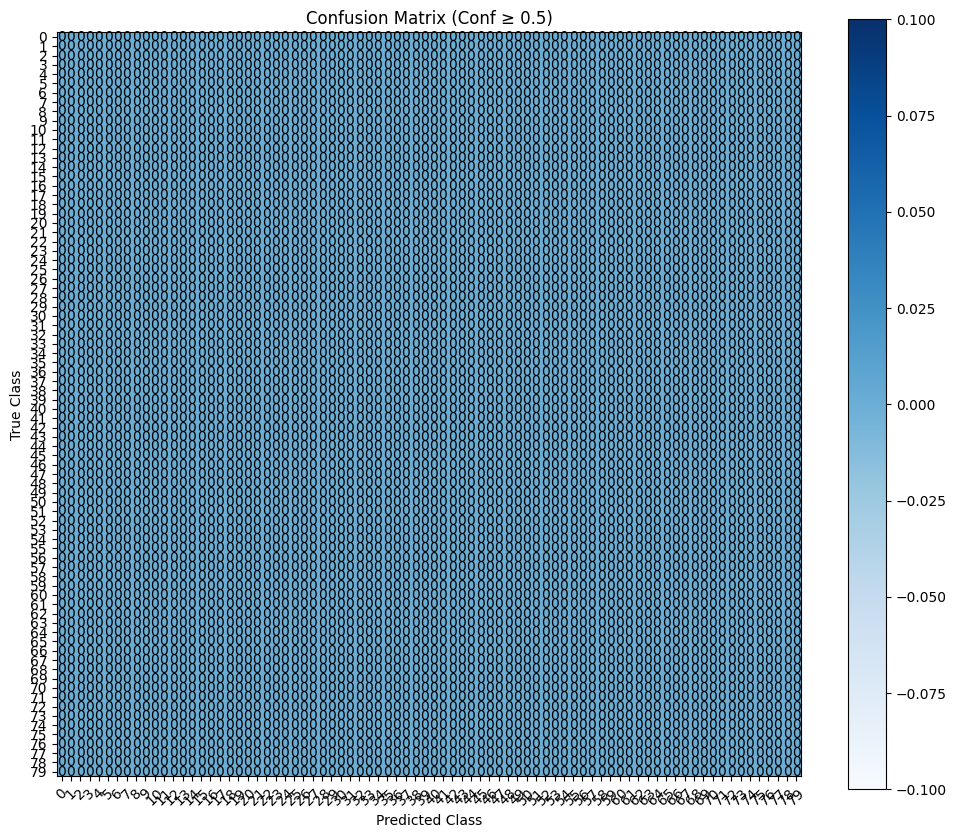

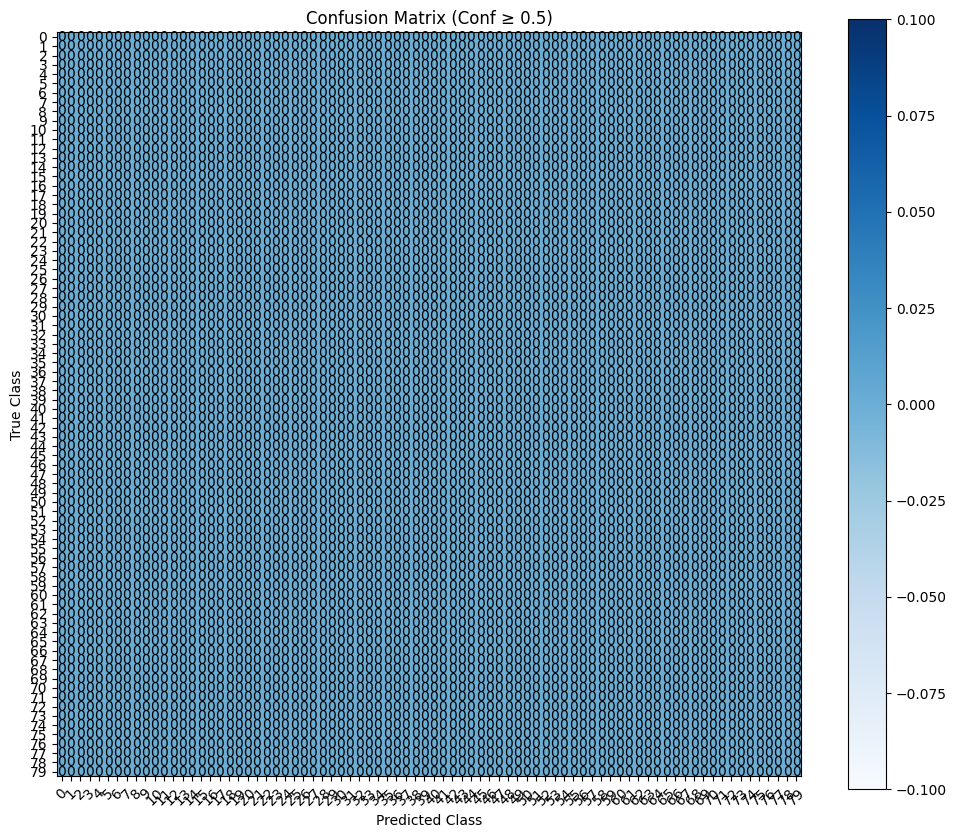

In [ ]:
cm = np.array(data['metrics']['confusion_matrix'])
metric_tracker2.plot_confusion_matrix(cm)